In [2]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from tqdm.notebook import tqdm
import os
import seaborn as sns
sns.set(style="whitegrid")

In [4]:
task_data = pd.read_csv("/Users/tinazhao/Documents/GitHub/Triceratop/data/bahav/processed_0.80/gambling_clean_data_all.csv")
model_assignment = pd.read_csv("/Users/tinazhao/Documents/GitHub/Triceratop/Analysis1_LLmodel/LL_model2_0.80.csv")
palette = {'Declarative' : 'tomato', 'Procedural' : 'steelblue'}

In [14]:
task_data

,Unnamed: 0,HCPID,Trial,RunNumber,TrialType,RunTrialNumber,Block,CurrentResponse,QuestionMark.ACC,RT,...,ConsecSameResp,ConsecLargerGuesses,ConsecSmallerGuesses,ConsecRTLess200,FutureResponse,PastResponse,ResponseSwitch,PreviousFeedback,BlockType,BlockTypeCoded
0,1,109830_fnca,1,1,Reward,2,5,2.0,0,572,...,1,0,1,0,2.0,NaN,NaN,NaN,MostlyReward,MostlyReward
1,2,109830_fnca,2,1,Reward,3,5,2.0,0,376,...,2,0,2,0,3.0,2.0,0.0,Reward,MostlyReward,MostlyReward
2,3,109830_fnca,3,1,Punishment,4,5,3.0,0,472,...,1,1,0,0,2.0,2.0,1.0,Reward,MostlyReward,MostlyReward
3,4,109830_fnca,4,1,Reward,5,5,2.0,0,343,...,1,0,1,0,2.0,3.0,1.0,Punishment,MostlyReward,MostlyReward
4,5,109830_fnca,5,1,Reward,6,5,2.0,0,440,...,2,0,2,0,2.0,2.0,0.0,Reward,MostlyReward,MostlyReward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63313,63314,826353_fnca,31,3,Punishment,29,5,2.0,0,448,...,4,0,4,0,2.0,2.0,0.0,Punishment,MostlyPunishment,MostlyPunishment
63314,63315,826353_fnca,32,3,Punishment,30,5,2.0,0,442,...,5,0,5,0,2.0,2.0,0.0,Punishment,MostlyPunishment,MostlyPunishment
63315,63316,826353_fnca,33,3,Punishment,31,5,2.0,0,408,...,6,0,6,0,2.0,2.0,0.0,Punishment,MostlyPunishment,MostlyPunishment
63316,63317,826353_fnca,34,3,Punishment,32,5,2.0,0,443,...,7,0,7,0,2.0,2.0,0.0,Punishment,MostlyPunishment,MostlyPunishment


In [6]:
alldata = pd.merge(task_data, model_assignment, on=["HCPID"])

# By Trial

In [7]:
bytrial = alldata.groupby(["HCPID", "TrialType", "best.model"], as_index=False).aggregate({'ResponseSwitch' : 'mean'})

bytrial=bytrial.reset_index()
bytrial.value_counts('best.model')

best.model
Procedural     2313
Declarative     630
Name: count, dtype: int64

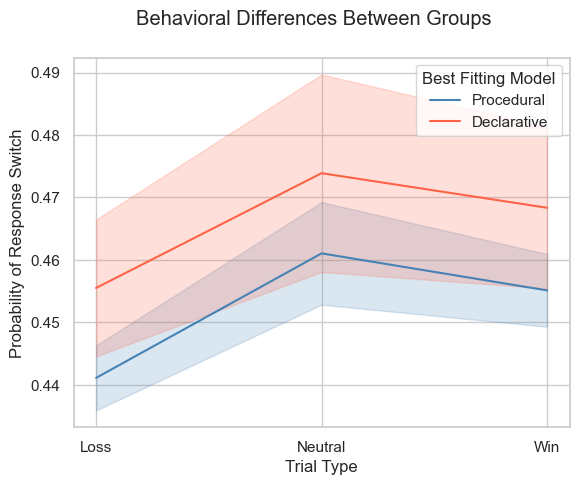

In [8]:
bytrial = bytrial.replace({"TrialType" : {"Reward" : "Win", "Punishment" : "Loss"}})
bytrial = bytrial.sort_values("TrialType")
ax = sns.lineplot(data=bytrial, x="TrialType", y="ResponseSwitch", hue="best.model", errorbar='se', sort=False, palette=palette)
ax.set(xlabel = "Trial Type", ylabel = "Probability of Response Switch")
plt.legend(loc='upper right', title="Best Fitting Model")
plt.suptitle("Behavioral Differences Between Groups")
plt.show()

# By Block

In [9]:
byblock = alldata.groupby(["HCPID", "BlockTypeCoded", "best.model"], as_index=False).aggregate({'ConsecSameResp' : 'max',
                                                                                               'ResponseSwitch' : 'mean'})
byblock = byblock.reset_index()
byblock = byblock.replace({"BlockTypeCoded" : {"MostlyReward" : "Mostly Wins", "MostlyPunishment" : "Mostly Losses"}})
byblock = byblock.sort_values("BlockTypeCoded")
byblock

,index,HCPID,BlockTypeCoded,best.model,ConsecSameResp,ResponseSwitch
0,0,100206_fnca,Mostly Losses,Declarative,4,0.392857
1098,1098,298455_fnca,Mostly Losses,Procedural,8,0.214286
1096,1096,298051_fnca,Mostly Losses,Procedural,6,0.230769
1094,1094,295146_fnca,Mostly Losses,Procedural,5,0.535714
1092,1092,293748_fnca,Mostly Losses,Procedural,5,0.357143
...,...,...,...,...,...,...
405,405,146836_fnca,Mostly Wins,Procedural,7,0.357143
1149,1149,329844_fnca,Mostly Wins,Procedural,4,0.500000
1147,1147,329440_fnca,Mostly Wins,Procedural,4,0.357143
1155,1155,336841_fnca,Mostly Wins,Declarative,6,0.500000


## Persistance

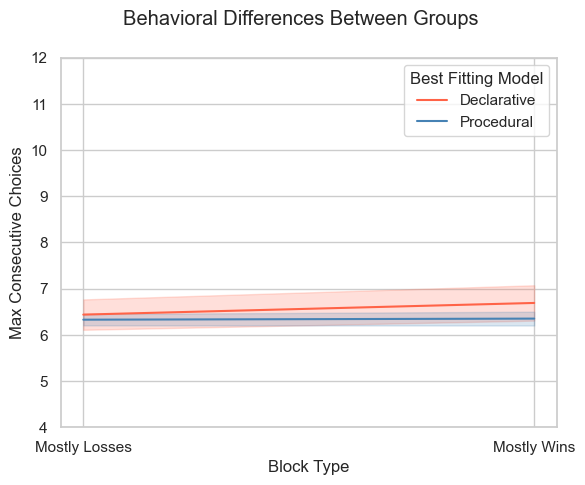

In [10]:
ax = sns.lineplot(data=byblock, x="BlockTypeCoded", y="ConsecSameResp", hue="best.model", errorbar='se', sort=False, palette=palette)
ax.set(xlabel = "Block Type", ylabel = "Max Consecutive Choices", ylim=(4, 12))
plt.legend(loc='upper right', title="Best Fitting Model")
plt.suptitle("Behavioral Differences Between Groups")
plt.show()

## Response SWitch

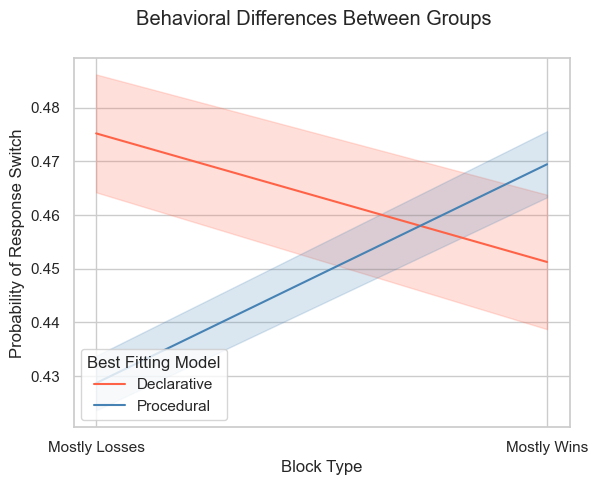

In [11]:
ax = sns.lineplot(data=byblock, x="BlockTypeCoded", y="ResponseSwitch", hue="best.model", errorbar='se', sort=False, palette=palette)
ax.set(xlabel = "Block Type", ylabel = "Probability of Response Switch")
plt.legend(loc='lower left', title="Best Fitting Model")
plt.suptitle("Behavioral Differences Between Groups")
plt.show()

# Article Figures


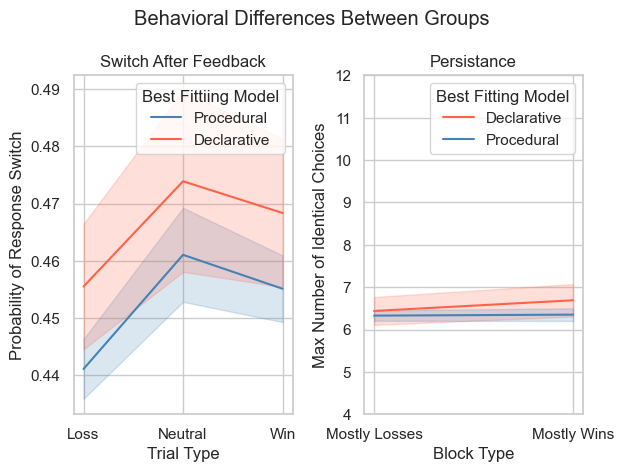

In [12]:
fig, axs = plt.subplots(1, 2)
ax = sns.lineplot(data=bytrial, x="TrialType", y="ResponseSwitch", hue="best.model", errorbar='se', sort=False, ax=axs[0], palette=palette)
ax.set(xlabel = "Trial Type", ylabel = "Probability of Response Switch", title="Switch After Feedback")
ax.legend(loc='upper right', title="Best Fittiing Model")

ax = sns.lineplot(data=byblock, x="BlockTypeCoded", y="ConsecSameResp", hue="best.model", errorbar='se', ax=axs[1], sort=False, palette=palette)
ax.set(xlabel = "Block Type", ylabel = "Max Number of Identical Choices", ylim=(4, 12), title="Persistance")
ax.legend(loc='upper right', title="Best Fitting Model")
plt.suptitle("Behavioral Differences Between Groups")
plt.tight_layout()
plt.show()